# EDA - Alzheimers Brain Structure
### Question
"How do the structural patterns in MRI scans differ across the four Alzheimer's Disease progression stages, and what imaging features might serve as early indicators of cognitive decline?"



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import cv2
import os

In [2]:
# Download Files
path = kagglehub.dataset_download("abdullahtauseef2003/adni-4c-alzheimers-mri-classification-dataset")
print("Path to dataset files:", path)

Path to dataset files: /Users/williamosborne/.cache/kagglehub/datasets/abdullahtauseef2003/adni-4c-alzheimers-mri-classification-dataset/versions/1


In [3]:
dataset_path = os.path.join(path, "AugmentedAlzheimerDataset")
categories = ["AD", "CN", "EMCI", "LMCI"]

/var/folders/tf/b53phpyj4wx950j43xmml5300000gn/T/ipykernel_60213/65665459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="viridis")


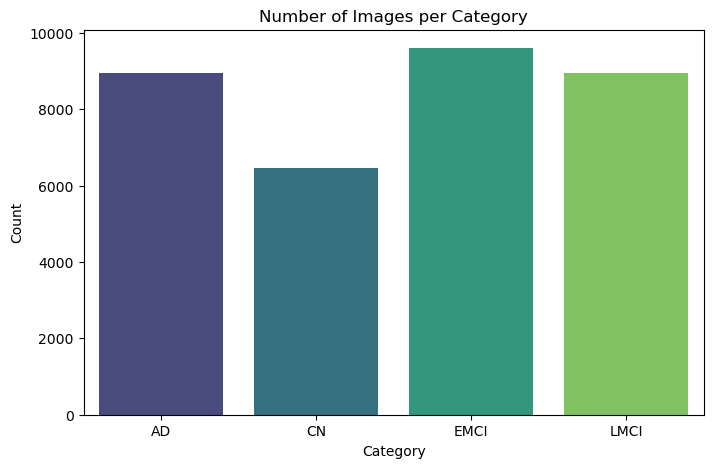

{'AD': 8960, 'CN': 6464, 'EMCI': 9600, 'LMCI': 8960}

In [16]:
image_counts = {category: len(os.listdir(os.path.join(dataset_path, category))) for category in categories}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="viridis")
plt.title("Number of Images per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

image_counts

In [5]:
#Check Image dimensions
img_dims = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    img_files = os.listdir(category_path)
    for img_file in img_files:
        img = cv2.imread(os.path.join(category_path, img_file), cv2.IMREAD_GRAYSCALE)
        if img is not None and img.shape not in img_dims:
            print(f"Unique Dimension: {img.shape}")
            img_dims.append(img.shape)

Unique Dimension: (190, 200)
Unique Dimension: (180, 180)


In [ ]:
# Resize all images to a square aspect ratio and load into memory

target_size = (190, 200)
images = {}

for category in categories:
    cat_path = os.path.join(dataset_path, category)
    img_files = os.listdir(cat_path)
    images[category] = []
    for img_f in img_files:
        img = cv2.imread(os.path.join(cat_path, img_f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
           r_img = cv2.resize(img, target_size)
           images[category].append(r_img)
           
len(images)

4

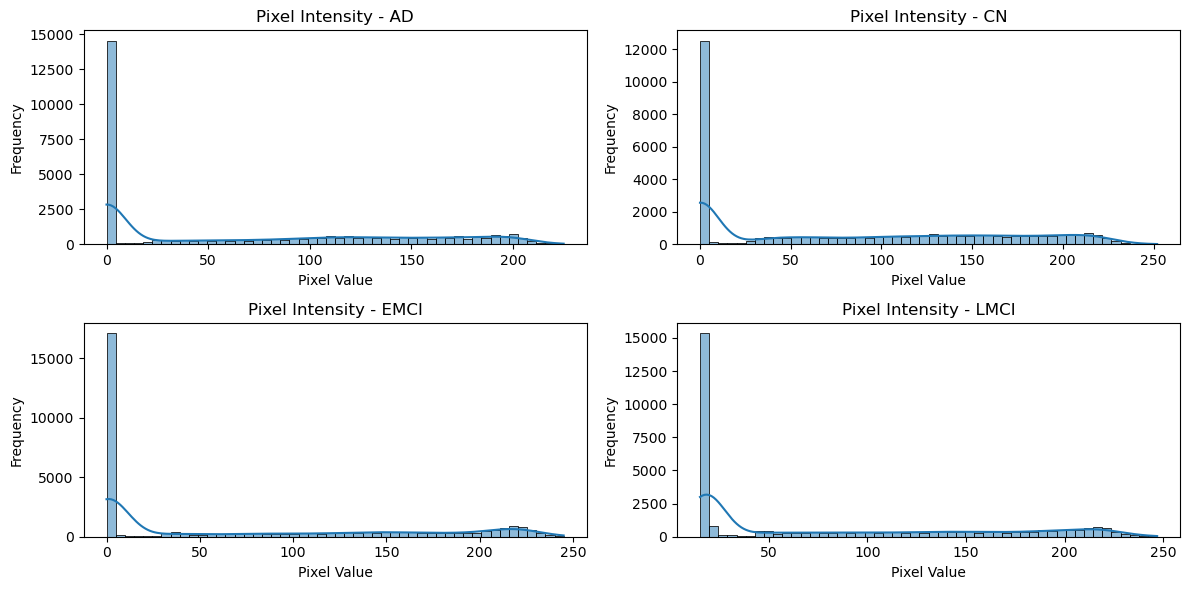

In [11]:
# Analyze pixel intensity distribution
plt.figure(figsize=(12, 6))
for i, category in enumerate(categories, 1):
    plt.subplot(2, 2, i)
    sample_img = images[category][0]
    sns.histplot(sample_img.flatten(), bins=50, kde=True)
    plt.title(f"Pixel Intensity - {category}")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

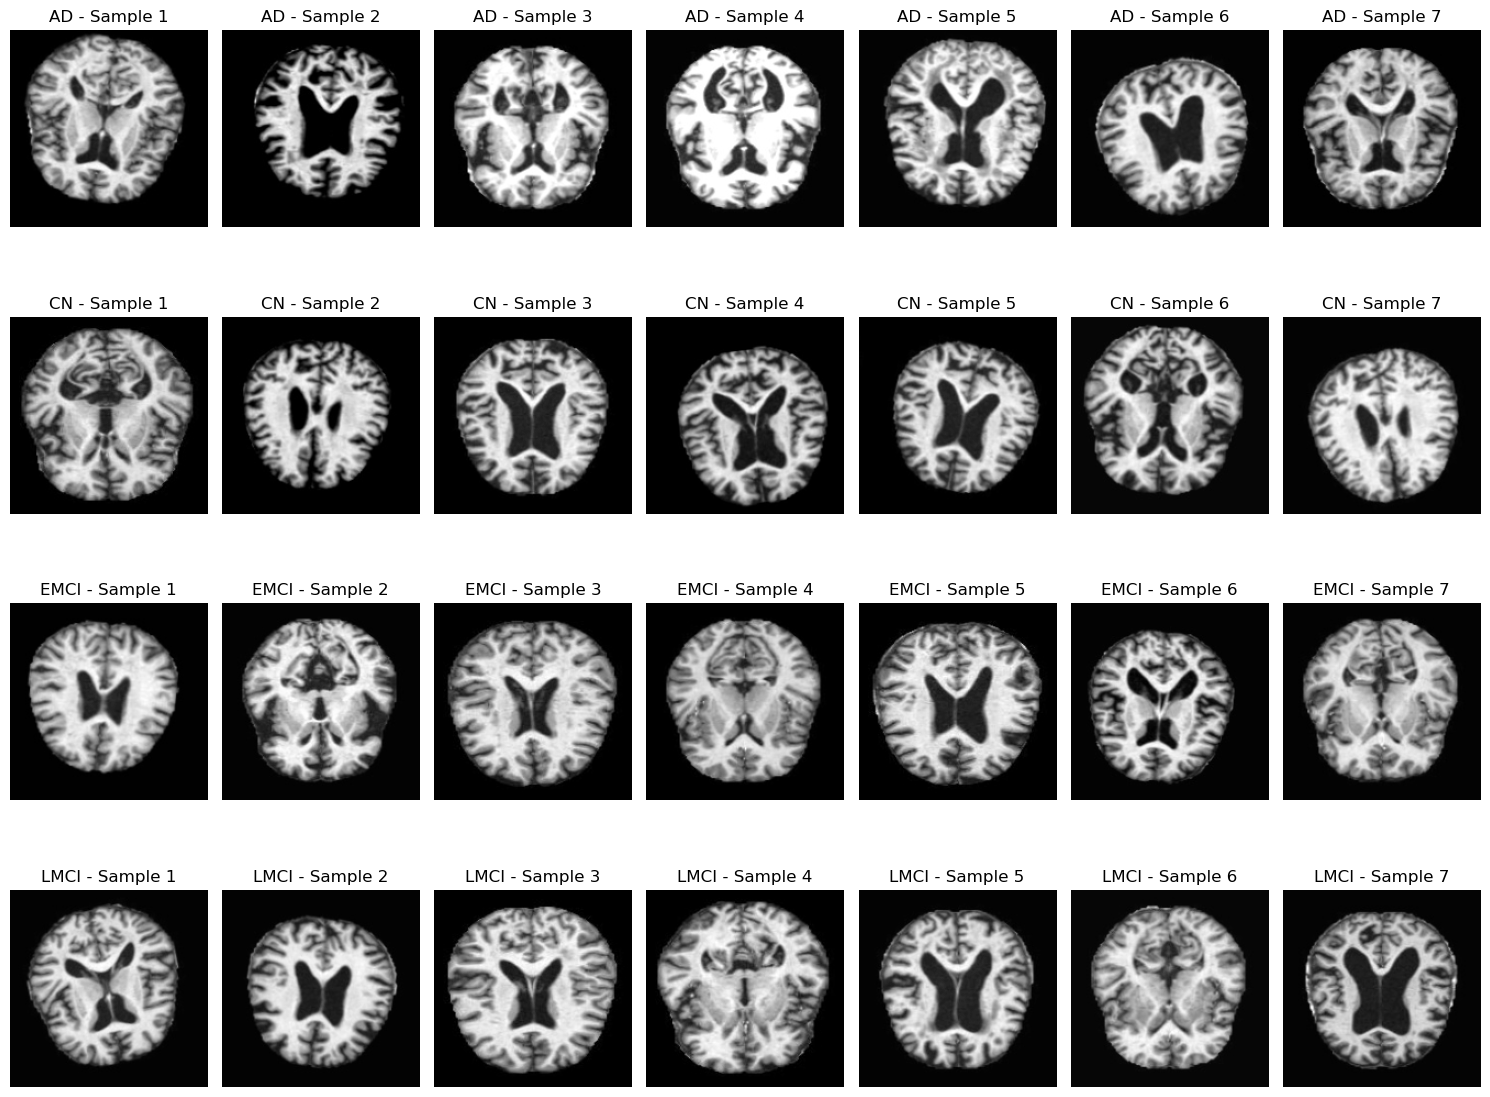

In [23]:
# Display multiple samples from each category
fig, axes = plt.subplots(4, 7, figsize=(15, 12))
for row, category in enumerate(categories):
    for col in range(7):
        img = images[category][col]
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{category} - Sample {col+1}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

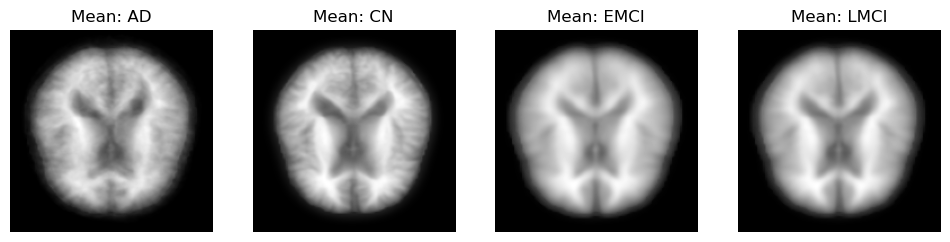

In [25]:
#Normalize images to (0, 1)
for category in images.keys():
    for img in images[category]:
        img = img / 255.0
        
mean_images = {
    "AD": np.mean(images['AD'][:50], axis=0),
    "CN": np.mean(images['CN'], axis=0),
    "EMCI": np.mean(images['EMCI'], axis=0),
    "LMCI": np.mean(images['LMCI'], axis=0)
}


# Display mean images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i, (label, mean_img) in enumerate(mean_images.items()):
    axes[i].imshow(mean_img, cmap="gray")
    axes[i].set_title(f"Mean: {label}")
    axes[i].axis("off")

plt.show()

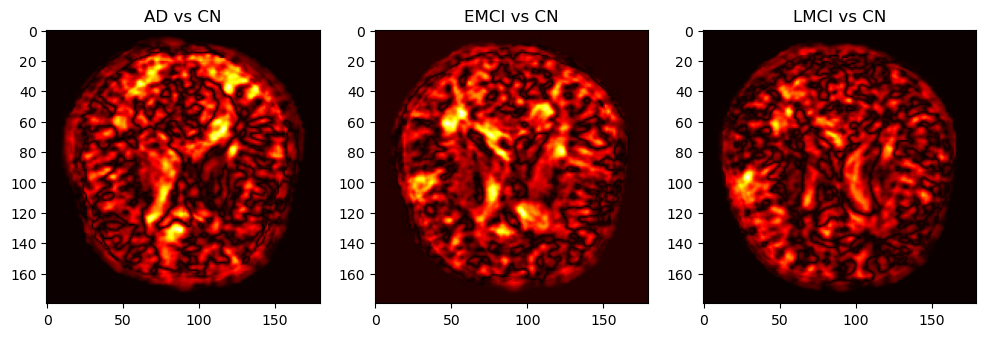

In [21]:
#Use image subtraction to identify differences between lables
diff_ad_cn = np.abs(mean_images["AD"] - mean_images["CN"])
diff_emci_cn = np.abs(mean_images["EMCI"] - mean_images["CN"])
diff_lmci_cn = np.abs(mean_images["LMCI"] - mean_images["CN"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(diff_ad_cn, cmap="hot")
axes[0].set_title("AD vs CN")

axes[1].imshow(diff_emci_cn, cmap="hot")
axes[1].set_title("EMCI vs CN")

axes[2].imshow(diff_lmci_cn, cmap="hot")
axes[2].set_title("LMCI vs CN")

plt.show()

In the above figure, group comparison images with brighter colors indicate more major structural differences